##### Hypothesis: Keyword influance rating and votes

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#0. Load data
data_path = "../../data/European_data_2000.csv"

df = pd.read_csv(
    data_path,
    sep=",",
    engine="python",
    quotechar='"',
    on_bad_lines="skip"   
)

Metric: There are 0 movies with 0 keywords (0.00% of the dataset).


/Users/meike/anaconda3/lib/python3.10/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


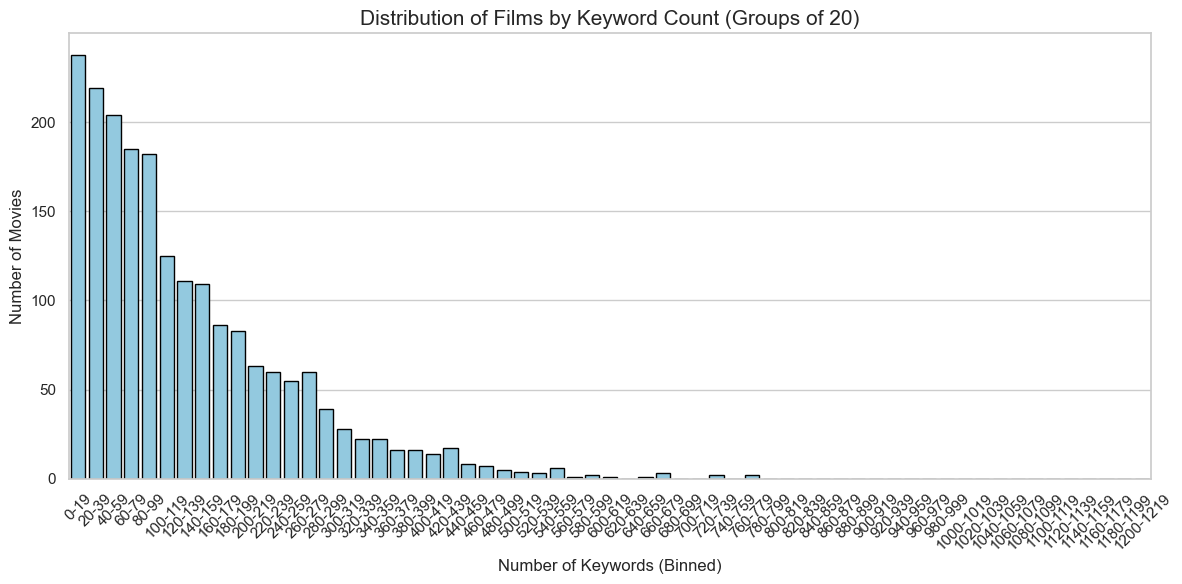

Average number of keywords: 132.36


In [96]:
# 1. Calculate Keyword Count
# We treat empty strings or NaNs as 0 keywords
df['keyword_count'] = df['keywords'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) and x != '' else 0)

# 2. METRIC: Movies with 0 Keywords
zero_kw_count = (df['keyword_count'] == 0).sum()
total_movies = len(df)
print(f"Metric: There are {zero_kw_count} movies with 0 keywords ({ (zero_kw_count/total_movies)*100:.2f}% of the dataset).")

# 3. Binning the Keyword Counts into groups of 5
# We create bins: [0, 5, 10, 15, ..., max+5]
max_kw = int(df['keyword_count'].max())
bins = list(range(0, max_kw + 6, 20))
labels = [f"{i}-{i+19}" for i in bins[:-1]]

df['kw_bins'] = pd.cut(df['keyword_count'], bins=bins, labels=labels, right=False)

# Set visual style
sns.set_theme(style="whitegrid")

# --- VISUALIZATION 1: Distribution of Binned Keyword Counts ---
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='kw_bins', color='skyblue', edgecolor='black')
plt.title('Distribution of Films by Keyword Count (Groups of 20)', fontsize=15)
plt.xlabel('Number of Keywords (Binned)', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df['keyword_count'] = df['keywords'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) and x != '' else 0)
print(f"Average number of keywords: {df['keyword_count'].mean():.2f}")




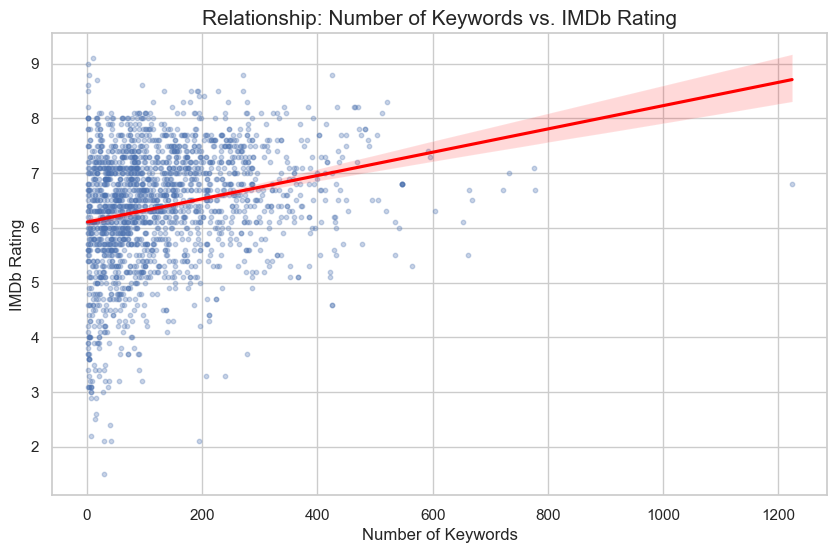

In [97]:
# --- VISUALIZATION 2: Keywords vs IMDb Rating ---
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='keyword_count', y='imdbRating', 
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
plt.title('Relationship: Number of Keywords vs. IMDb Rating', fontsize=15)
plt.xlabel('Number of Keywords', fontsize=12)
plt.ylabel('IMDb Rating', fontsize=12)
plt.show()

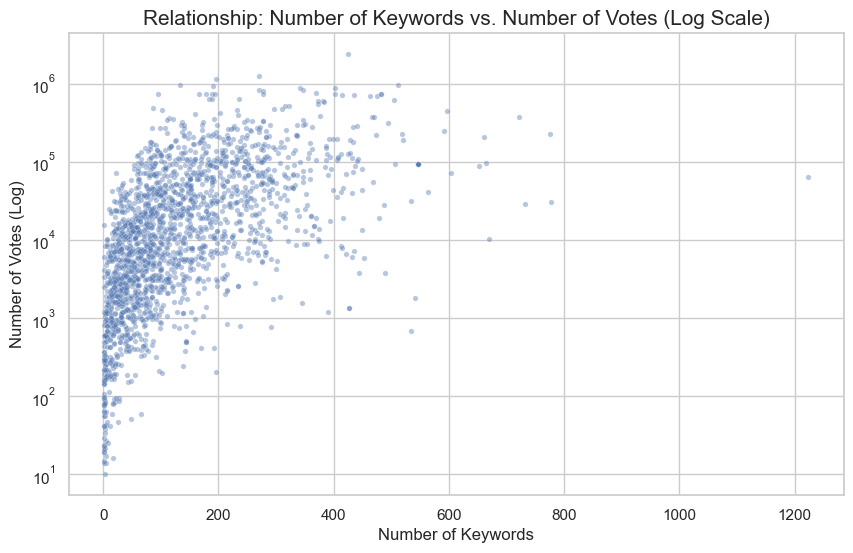

Correlation Matrix:
keyword_count    1.000000
imdbRating       0.239988
numberOfVotes    0.391785
Name: keyword_count, dtype: float64


In [98]:
# --- VISUALIZATION 3: Keywords vs Number of Votes ---
# Note: numberOfVotes often follows a power-law distribution, so a log scale helps visibility.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='keyword_count', y='numberOfVotes', alpha=0.4, s=15)
plt.yscale('log')  # Using log scale for votes to handle high variance
plt.title('Relationship: Number of Keywords vs. Number of Votes (Log Scale)', fontsize=15)
plt.xlabel('Number of Keywords', fontsize=12)
plt.ylabel('Number of Votes (Log)', fontsize=12)
plt.show()

# --- Statistical Check: Correlation ---
correlations = df[['keyword_count', 'imdbRating', 'numberOfVotes']].corr()
print("Correlation Matrix:")
print(correlations['keyword_count'])

### Insights
The relationship between keywords and ratings is positive but weak, meaning that more keywords also have better ratings. 
The relationship between keywords and votes is stronger, suggesting that keywords with more votes also have more keywords.
* More keywords open the movie to a wider audience.
* However, this could also mean that a popular movie brings more engagement from fans who leave more keywords on IMDb.
### Questions: 
* How are keywords set? 
* How can you identify which keywords are set by the community and which are from the production team?
* As votes are a good indicator of box office performance, what about keywords? 

## Sentiment analysis

First try with VADER. But maybe the model needs to be changed to BERT

In [99]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if pd.isnull(text) or text == '':
        return 0
    return sia.polarity_scores(str(text))['compound']

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/meike/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


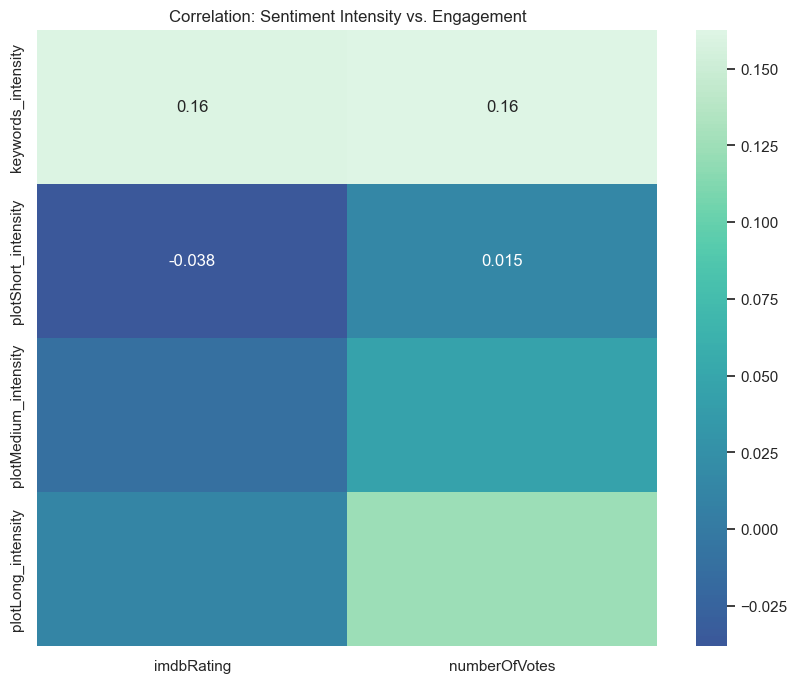

                      keywords_intensity  plotShort_intensity  \
keywords_intensity              1.000000             0.077809   
plotShort_intensity             0.077809             1.000000   
plotMedium_intensity            0.034192             0.157081   
plotLong_intensity              0.161394             0.036516   
imdbRating                      0.159633            -0.037992   
numberOfVotes                   0.162678             0.015095   

                      plotMedium_intensity  plotLong_intensity  imdbRating  \
keywords_intensity                0.034192            0.161394    0.159633   
plotShort_intensity               0.157081            0.036516   -0.037992   
plotMedium_intensity              1.000000            0.089032   -0.011394   
plotLong_intensity                0.089032            1.000000    0.011518   
imdbRating                       -0.011394            0.011518    1.000000   
numberOfVotes                     0.045044            0.122740    0.330063  

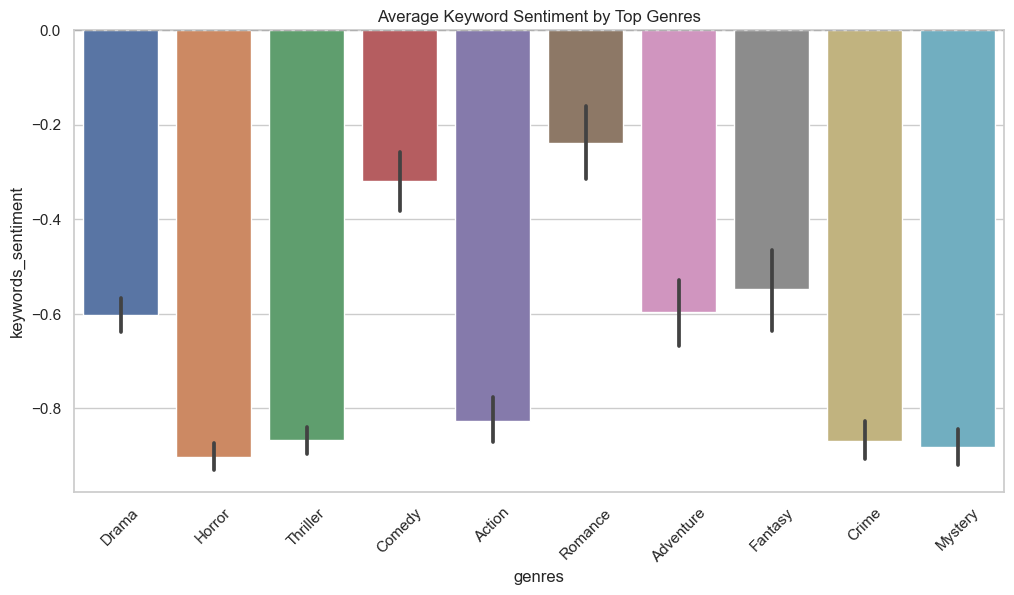

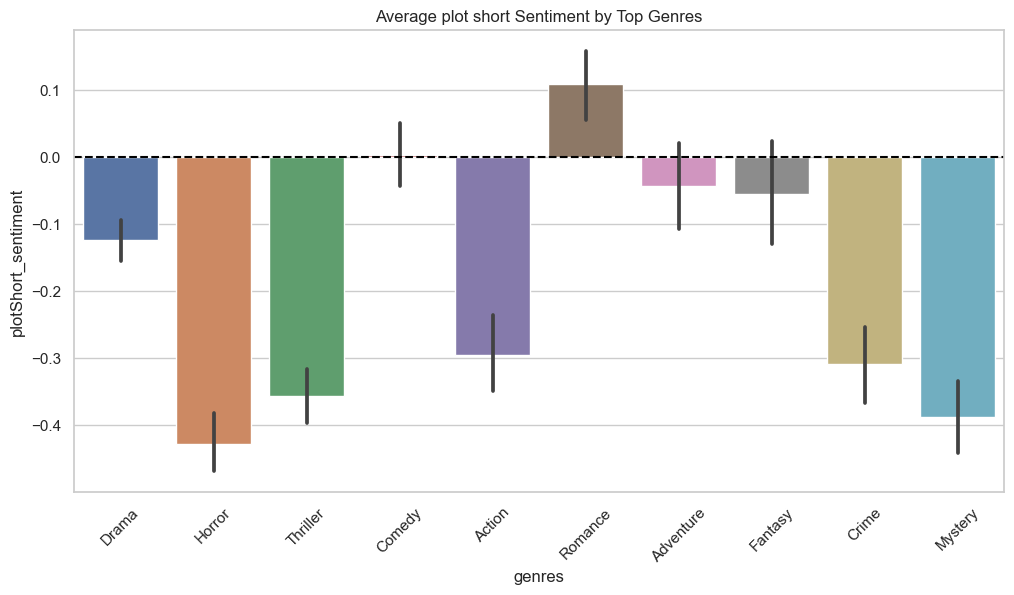

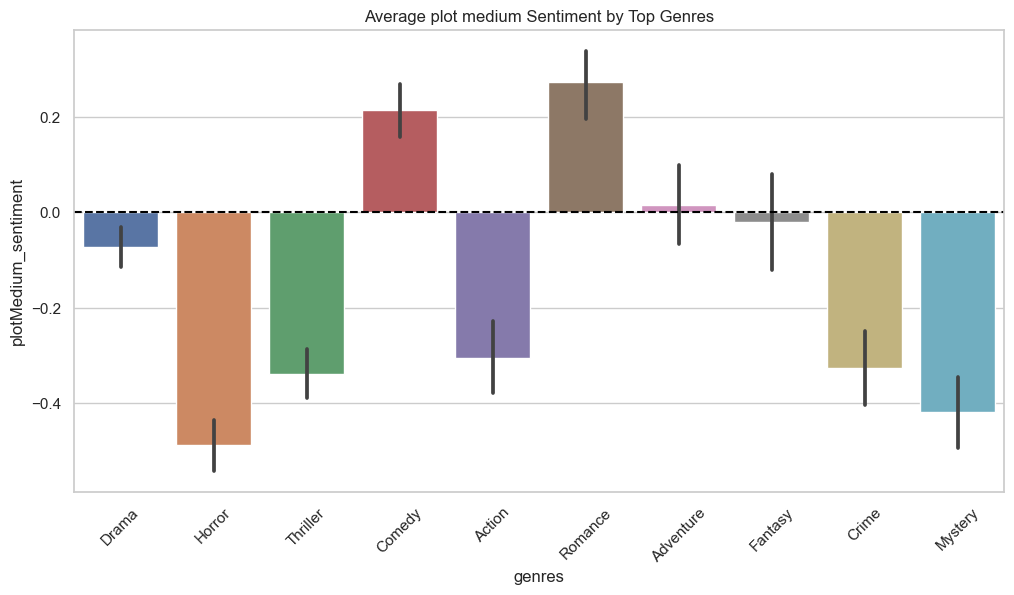

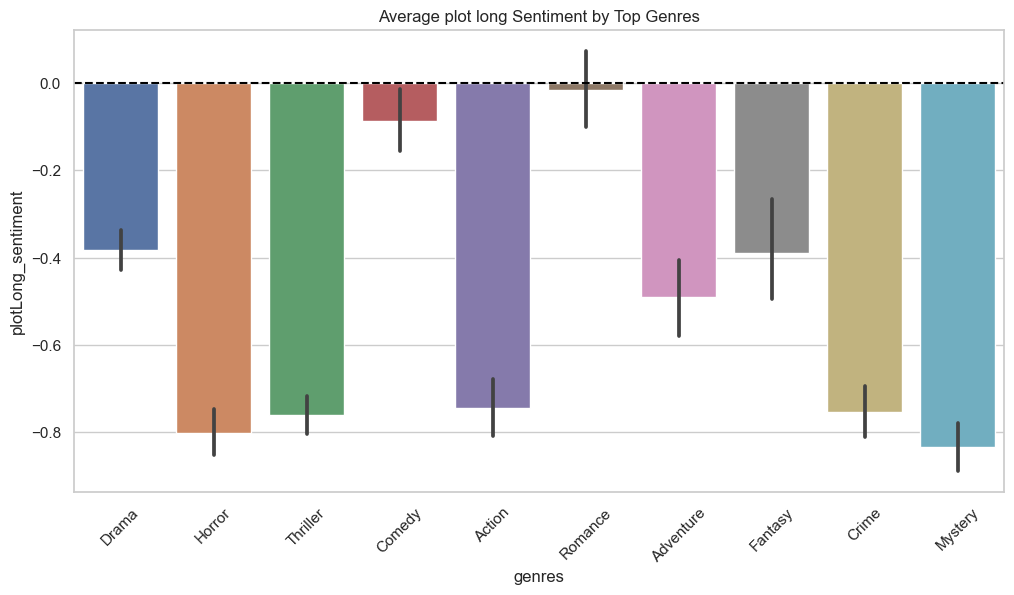

In [100]:
# 1. Calculate Sentiment for Keywords and Plots
cols_to_analyze = ['keywords', 'plotShort', 'plotMedium', 'plotLong']

for col in cols_to_analyze:
    # Get the raw sentiment (-1 to 1)
    df[f'{col}_sentiment'] = df[col].apply(get_sentiment)
    # Get the intensity (0 to 1) - because "Strong" sentiment can be +/-
    df[f'{col}_intensity'] = df[f'{col}_sentiment'].abs()

# 2. Correlation Check
sentiment_cols = [f'{col}_intensity' for col in cols_to_analyze]
engagement_cols = ['imdbRating', 'numberOfVotes']
corr_matrix = df[sentiment_cols + engagement_cols].corr()

# --- Visualization 1: Heatmap of Sentiment vs Engagement ---
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix[engagement_cols].loc[sentiment_cols], annot=True, cmap='mako', center=0)
plt.title('Correlation: Sentiment Intensity vs. Engagement')
plt.show()
print(corr_matrix)

# 3. Genre Analysis
# We need to split movies that have multiple genres like "Drama, Comedy"
df_genre = df.assign(genres=df['genres'].str.split(',')).explode('genres')
df_genre['genres'] = df_genre['genres'].str.strip()

# --- Visualization 2: Sentiment Strategy by Genre ---
# Let's look at keywords sentiment vs Rating across top genres
top_genres = df_genre['genres'].value_counts().nlargest(10).index
df_top_genres = df_genre[df_genre['genres'].isin(top_genres)]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_genres, x='genres', y='keywords_sentiment', hue=None)
plt.axhline(0, color='black', linestyle='--')
plt.title('Average Keyword Sentiment by Top Genres')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_genres, x='genres', y='plotShort_sentiment', hue=None)
plt.axhline(0, color='black', linestyle='--')
plt.title('Average plot short Sentiment by Top Genres')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_genres, x='genres', y='plotMedium_sentiment', hue=None)
plt.axhline(0, color='black', linestyle='--')
plt.title('Average plot medium Sentiment by Top Genres')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_genres, x='genres', y='plotLong_sentiment', hue=None)
plt.axhline(0, color='black', linestyle='--')
plt.title('Average plot long Sentiment by Top Genres')
plt.xticks(rotation=45)
plt.show()

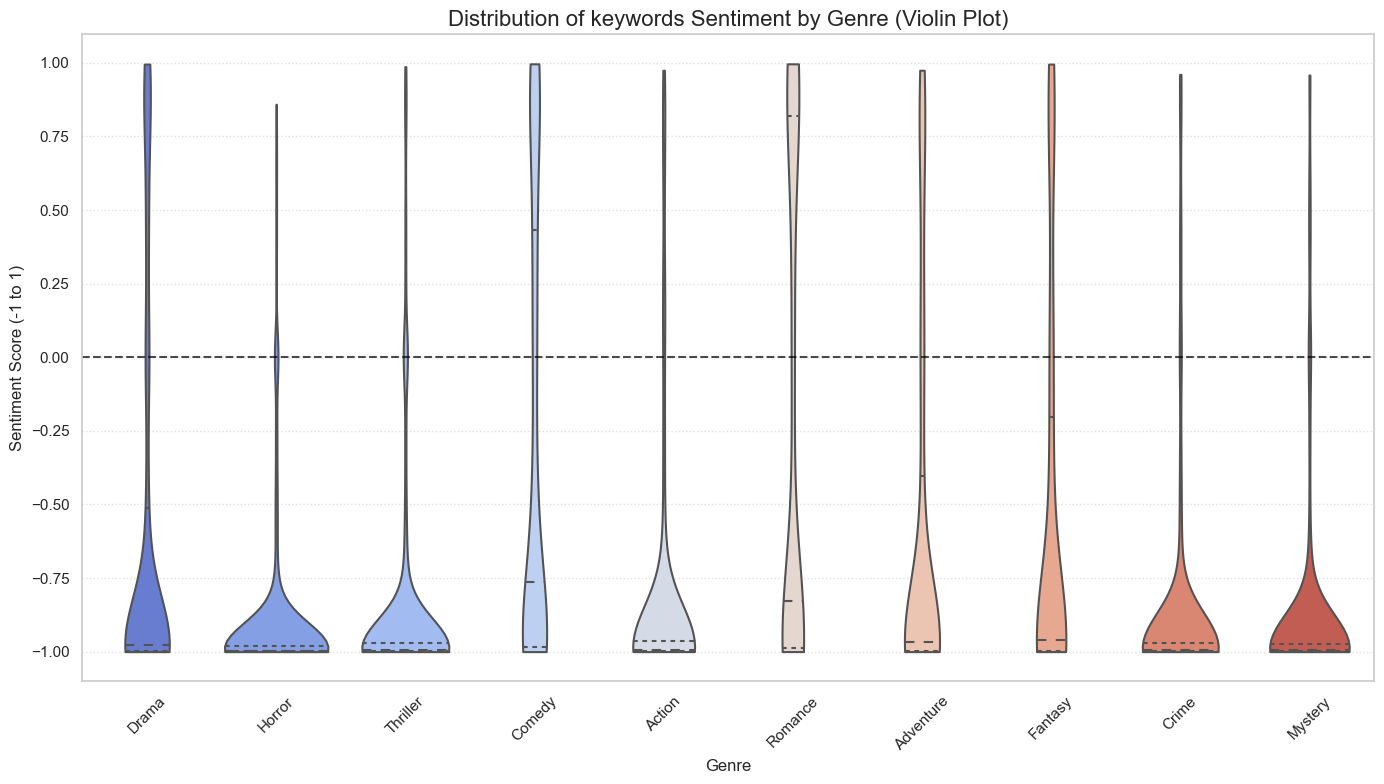

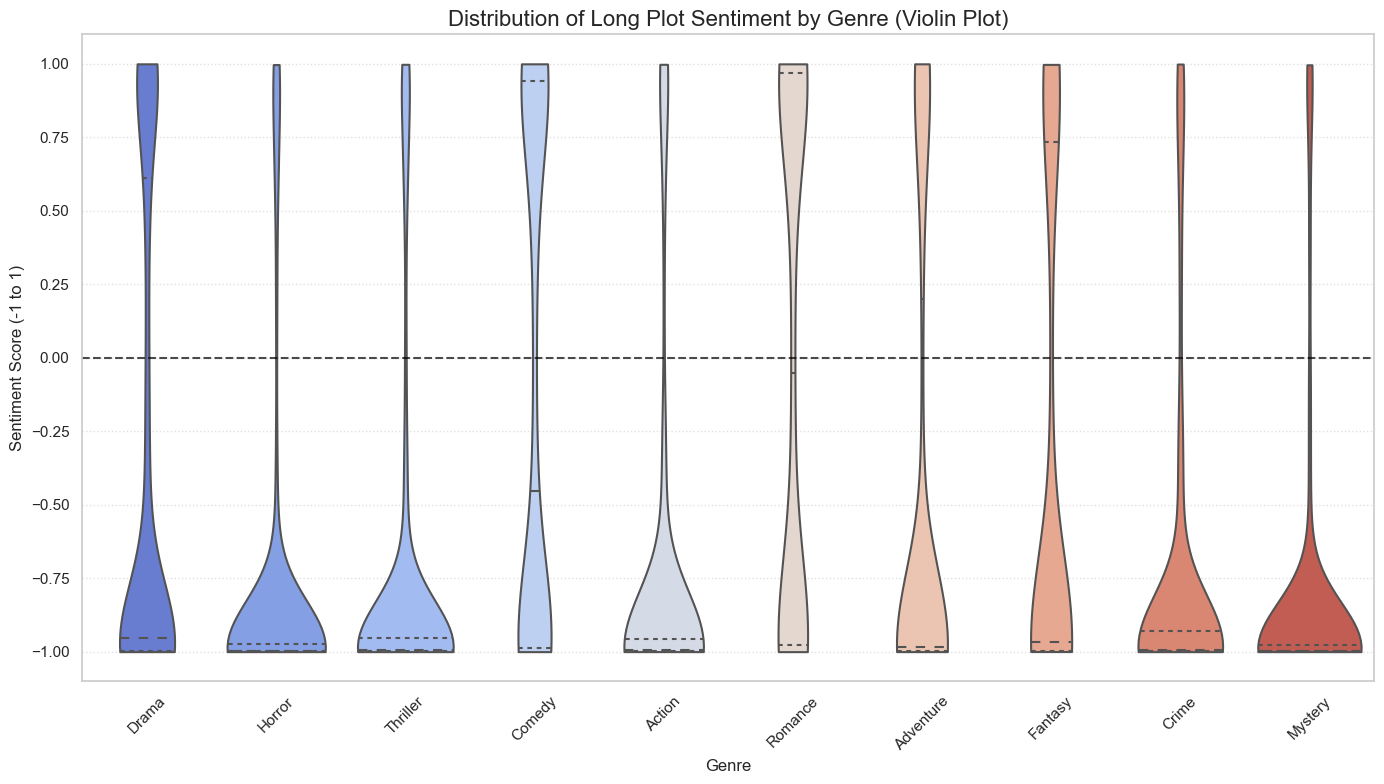

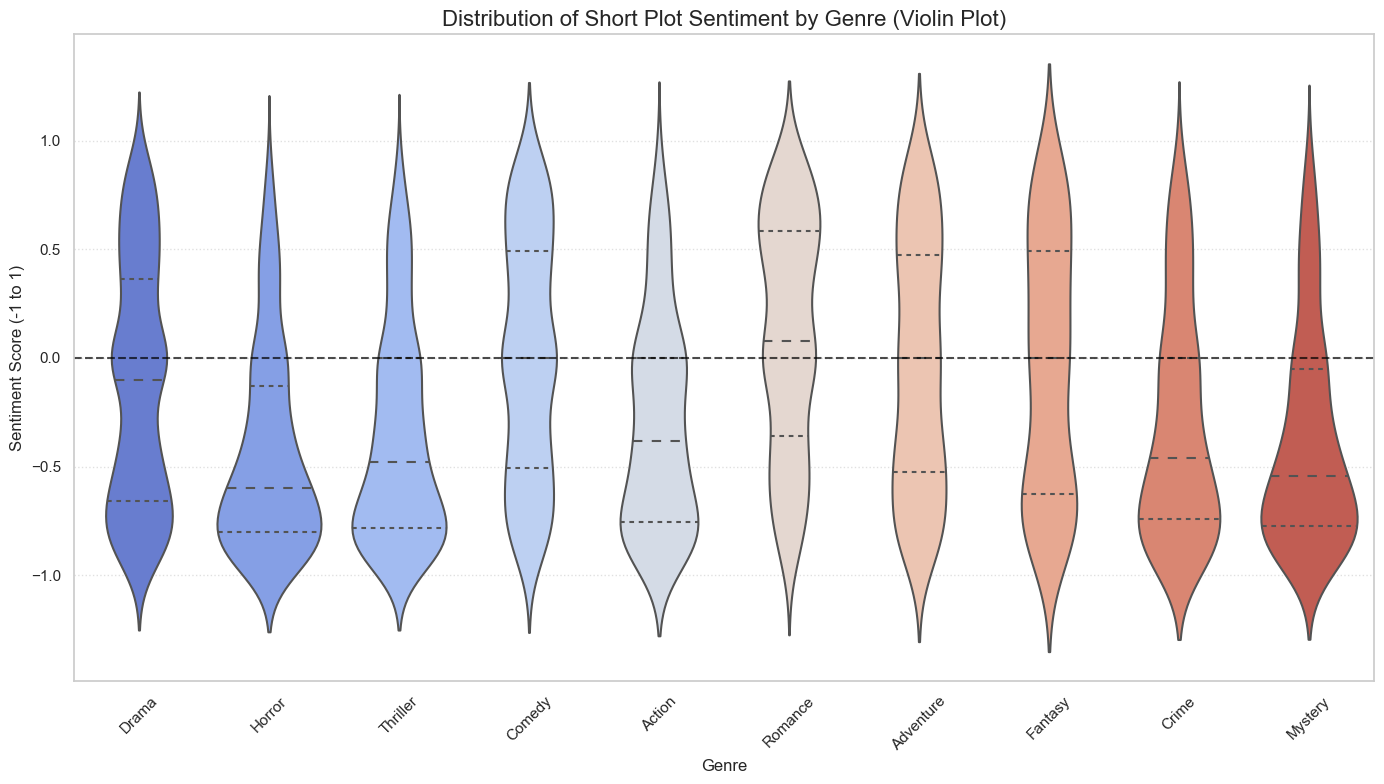

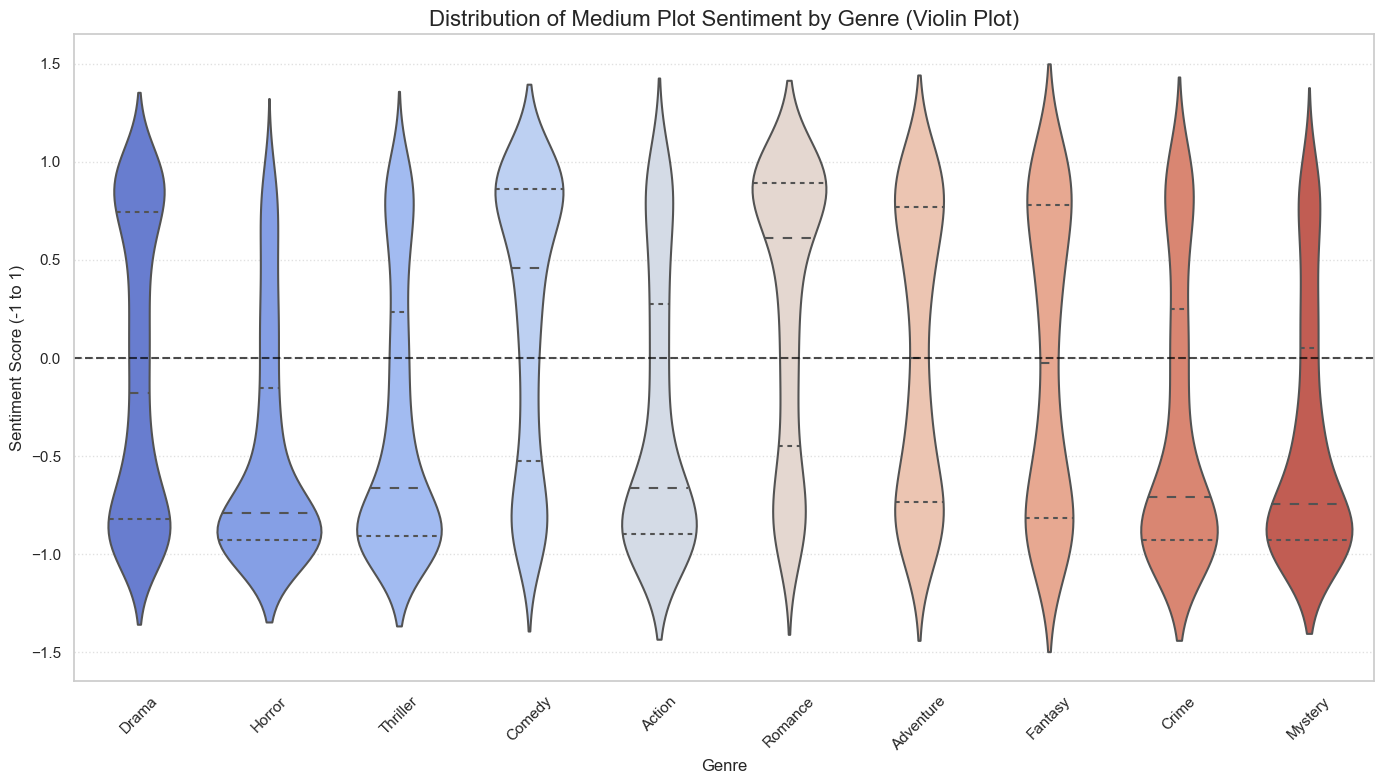

In [101]:
plt.figure(figsize=(14, 8))
# Create the Violin Plot
sns.violinplot(data=df_top_genres, x='genres', y='keywords_sentiment', 
               palette="coolwarm", inner="quartile", cut=0)
# Add a reference line at 0 (Neutral)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.title('Distribution of keywords Sentiment by Genre (Violin Plot)', fontsize=16)
plt.ylabel('Sentiment Score (-1 to 1)', fontsize=12)
plt.xlabel('Genre', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 8))
# Create the Violin Plot
sns.violinplot(data=df_top_genres, x='genres', y='plotLong_sentiment', 
               palette="coolwarm", inner="quartile", cut=0)
# Add a reference line at 0 (Neutral)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.title('Distribution of Long Plot Sentiment by Genre (Violin Plot)', fontsize=16)
plt.ylabel('Sentiment Score (-1 to 1)', fontsize=12)
plt.xlabel('Genre', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 8))
# Create the Violin Plot
sns.violinplot(data=df_top_genres, x='genres', y='plotShort_sentiment', 
               palette="coolwarm", inner="quartile")
# Add a reference line at 0 (Neutral)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.title('Distribution of Short Plot Sentiment by Genre (Violin Plot)', fontsize=16)
plt.ylabel('Sentiment Score (-1 to 1)', fontsize=12)
plt.xlabel('Genre', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 8))
# Create the Violin Plot
sns.violinplot(data=df_top_genres, x='genres', y='plotMedium_sentiment', 
               palette="coolwarm", inner="quartile")
# Add a reference line at 0 (Neutral)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.title('Distribution of Medium Plot Sentiment by Genre (Violin Plot)', fontsize=16)
plt.ylabel('Sentiment Score (-1 to 1)', fontsize=12)
plt.xlabel('Genre', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [102]:
import pandas as pd
import numpy as np
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Ensure VADER is ready
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

# 1. Helper function to categorize sentiment
def categorize_sentiment(score):
    if score > 0.05: return 'Positive'
    elif score < -0.05: return 'Negative'
    else: return 'Neutral'

# 2. Sentiment Calculation (if not already done)
text_cols = ['keywords', 'plotShort'] # Using these two as primary indicators
for col in text_cols:
    df[f'{col}_sentiment_score'] = df[col].apply(lambda x: sia.polarity_scores(str(x))['compound'] if pd.notnull(x) else 0)
    df[f'{col}_sentiment_type'] = df[f'{col}_sentiment_score'].apply(categorize_sentiment)

# 3. Process Genres (Explode so each film counts for each of its genres)
df_exploded = df.assign(genres=df['genres'].str.split(',')).explode('genres')
df_exploded['genres'] = df_exploded['genres'].str.strip()

# 4. Filter for Top Genres (to keep the table readable)
top_genres = df_exploded['genres'].value_counts().nlargest(15).index
df_top = df_exploded[df_exploded['genres'].isin(top_genres)]

# 5. Create the Strategy Table Logic
# We want to find which sentiment type has the highest mean rating per genre
strategy_data = []

for genre in top_genres:
    genre_subset = df_top[df_top['genres'] == genre]
    
    # Keyword Strategy
    best_kw_sent = genre_subset.groupby('keywords_sentiment_type')['imdbRating'].mean().idxmax()
    kw_rating = genre_subset.groupby('keywords_sentiment_type')['imdbRating'].mean().max()
    
    # Plot Strategy
    best_plot_sent = genre_subset.groupby('plotShort_sentiment_type')['imdbRating'].mean().idxmax()
    plot_rating = genre_subset.groupby('plotShort_sentiment_type')['imdbRating'].mean().max()
    
    # Average Votes for context
    avg_votes = genre_subset['numberOfVotes'].median()
    
    strategy_data.append({
        'Genre': genre,
        'Recommended Keyword Vibe': best_kw_sent,
        'Recommended Plot Vibe': best_plot_sent,
        'Target Rating (Est.)': round(kw_rating, 2),
        'Typical Genre Reach (Median Votes)': int(avg_votes)
    })

strategy_df = pd.DataFrame(strategy_data)

# Display the table
print("--- STRATEGY TABLE FOR DIRECTORS ---")
print(strategy_df.to_string(index=False))

# Optional: Save to CSV for your report
# strategy_df.to_csv('genre_sentiment_strategy.csv', index=False)

--- STRATEGY TABLE FOR DIRECTORS ---
    Genre Recommended Keyword Vibe Recommended Plot Vibe  Target Rating (Est.)  Typical Genre Reach (Median Votes)
    Drama                 Negative              Positive                  6.69                               13639
 Thriller                 Negative              Positive                  6.28                               18785
   Comedy                 Negative              Positive                  6.34                               13073
  Romance                 Negative               Neutral                  6.57                               13220
   Horror                 Negative              Positive                  5.78                                7448
Adventure                 Negative              Positive                  6.24                               20380
    Crime                 Negative              Negative                  6.58                               19543
   Action                 Negative         

In [103]:
# Check how many movies are actually in each category for Comedy
comedy_check = df_top[df_top['genres'] == 'Comedy']
print(comedy_check['keywords_sentiment_type'].value_counts())

# Check the actual mean ratings to see how close they are
print(comedy_check.groupby('keywords_sentiment_type')['imdbRating'].mean())

keywords_sentiment_type
Negative    342
Positive    171
Neutral      17
Name: count, dtype: int64
keywords_sentiment_type
Negative    6.338596
Neutral     5.776471
Positive    6.245029
Name: imdbRating, dtype: float64


## See results for BERT modulle

## Network analysis for Genres

In [104]:
import pandas as pd
import itertools

# 1. Preparation: Clean genres and split into lists
# We handle the 'genres' column, splitting by comma and stripping whitespace
df['genre_list'] = df['genres'].fillna('').str.split(',')
df['genre_list'] = df['genre_list'].apply(lambda x: [g.strip() for g in x if g.strip()])

# 2. Generate EDGES (Genre A <-> Genre B)
genre_edges_list = []

for _, row in df.iterrows():
    genres = sorted(row['genre_list'])
    if len(genres) > 1:
        # Create all possible pairs within one movie (e.g., Drama-Comedy, Drama-Romance)
        pairs = list(itertools.combinations(genres, 2))
        genre_edges_list.extend(pairs)

# Convert to DataFrame and aggregate weights (how many movies share these genres)
genre_edges_df = pd.DataFrame(genre_edges_list, columns=['Source', 'Target'])
gephi_genre_edges = genre_edges_df.groupby(['Source', 'Target']).size().reset_index(name='Weight')

# 3. Generate NODES (with average rating as a property)
# This allows you to color nodes in Gephi by how well that genre typically performs
genre_stats = df.assign(genres=df['genres'].str.split(',')).explode('genres')
genre_stats['genres'] = genre_stats['genres'].str.strip()
avg_ratings = genre_stats.groupby('genres')['imdbRating'].mean().to_dict()

unique_genres = sorted(list(set([g for sublist in df['genre_list'] for g in sublist])))
nodes_data = [
    {'Id': g, 'Label': g, 'AvgRating': avg_ratings.get(g, 0)} 
    for g in unique_genres
]
gephi_genre_nodes = pd.DataFrame(nodes_data)

# 4. Export for Gephi Lite
gephi_genre_nodes.to_csv('../assets/data_for_networks/genre_nodes.csv', index=False)
gephi_genre_edges.to_csv('../assets/data_for_networks/genre_edges.csv', index=False)

print(f"Genre network ready! Nodes: {len(gephi_genre_nodes)}, Edges: {len(gephi_genre_edges)}")

Genre network ready! Nodes: 24, Edges: 197


In [105]:
#GEXF genre
import pandas as pd
import itertools
import xml.etree.ElementTree as ET
from xml.dom import minidom

# 1. Data Preparation (Genres)
df['genre_list'] = df['genres'].fillna('').str.split(',')
df['genre_list'] = df['genre_list'].apply(lambda x: [g.strip() for g in x if g.strip()])

# 2. Get Statistics for Nodes
genre_stats = df.assign(genres=df['genres'].str.split(',')).explode('genres')
genre_stats['genres'] = genre_stats['genres'].str.strip()
avg_ratings = genre_stats.groupby('genres')['imdbRating'].mean().to_dict()
count_per_genre = genre_stats.groupby('genres').size().to_dict()
unique_genres = sorted(list(set([g for sublist in df['genre_list'] for g in sublist])))

# 3. Generate Edges
genre_edges_list = []
for _, row in df.iterrows():
    genres = sorted(row['genre_list'])
    if len(genres) > 1:
        pairs = list(itertools.combinations(genres, 2))
        genre_edges_list.extend(pairs)

genre_edges_df = pd.DataFrame(genre_edges_list, columns=['source', 'target'])
gephi_genre_edges = genre_edges_df.groupby(['source', 'target']).size().reset_index(name='weight')

# 4. Build GEXF XML Structure
gexf = ET.Element('gexf', xmlns='http://www.gexf.net/1.2draft', version='1.2')
graph = ET.SubElement(gexf, 'graph', defaultedgetype='undirected')

# Define Attributes (Rating and Movie Count)
attributes = ET.SubElement(graph, 'attributes', {'class': 'node'})
ET.SubElement(attributes, 'attribute', id='0', title='avg_rating', type='float')
ET.SubElement(attributes, 'attribute', id='1', title='movie_count', type='integer')

# Add Nodes
nodes = ET.SubElement(graph, 'nodes')
for i, g in enumerate(unique_genres):
    node = ET.SubElement(nodes, 'node', id=str(g), label=str(g))
    attvalues = ET.SubElement(node, 'attvalues')
    
    # We use a dictionary {'for': '0'} to bypass the Python reserved word 'for'
    ET.SubElement(attvalues, 'attvalue', {'for': '0', 'value': str(round(avg_ratings.get(g, 0), 2))})
    ET.SubElement(attvalues, 'attvalue', {'for': '1', 'value': str(count_per_genre.get(g, 0))})

# Add Edges
edges = ET.SubElement(graph, 'edges')
for i, row in gephi_genre_edges.iterrows():
    ET.SubElement(edges, 'edge', id=str(i), source=row['source'], target=row['target'], weight=str(row['weight']))

# 5. Format and Save
xml_str = ET.tostring(gexf, encoding='utf-8')
reparsed = minidom.parseString(xml_str)
pretty_xml = reparsed.toprettyxml(indent="  ")

file_path = '../assets/data_for_networks/genre_network.gexf'
with open(file_path, "w", encoding="utf-8") as f:
    f.write(pretty_xml)

print(f"GEXF file successfully created at {file_path}!")

GEXF file successfully created at ../assets/data_for_networks/genre_network.gexf!


## Heatmap for Genre 
Frequency Heatmap: Shows which genres are most commonly paired (the "Industry Standard" combinations).

Quality Heatmap: Shows which pairings result in the highest average IMDb ratings (the "Critical Success" combinations).

#### Interpretion help (gemini)
The "Mass Market" Zone (Frequency Heatmap): Look for the darkest blue squares. Usually, combinations like Drama-Romance or Crime-Thriller are the most frequent. This represents the "safe" territory where most European directors currently operate.

The "Golden Opportunity" Zone (Rating Heatmap): Look for dark green squares that correspond to light blue squares in the first map.

If a pairing (e.g., Drama-History) has a high rating but a low frequency, you can tell the director: "This is a high-quality niche with low competition."

The "Avoid" Zone: Red or orange squares in the Rating heatmap indicate combinations that typically struggle to win over audiences or critics.

/Users/meike/anaconda3/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)
/Users/meike/anaconda3/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


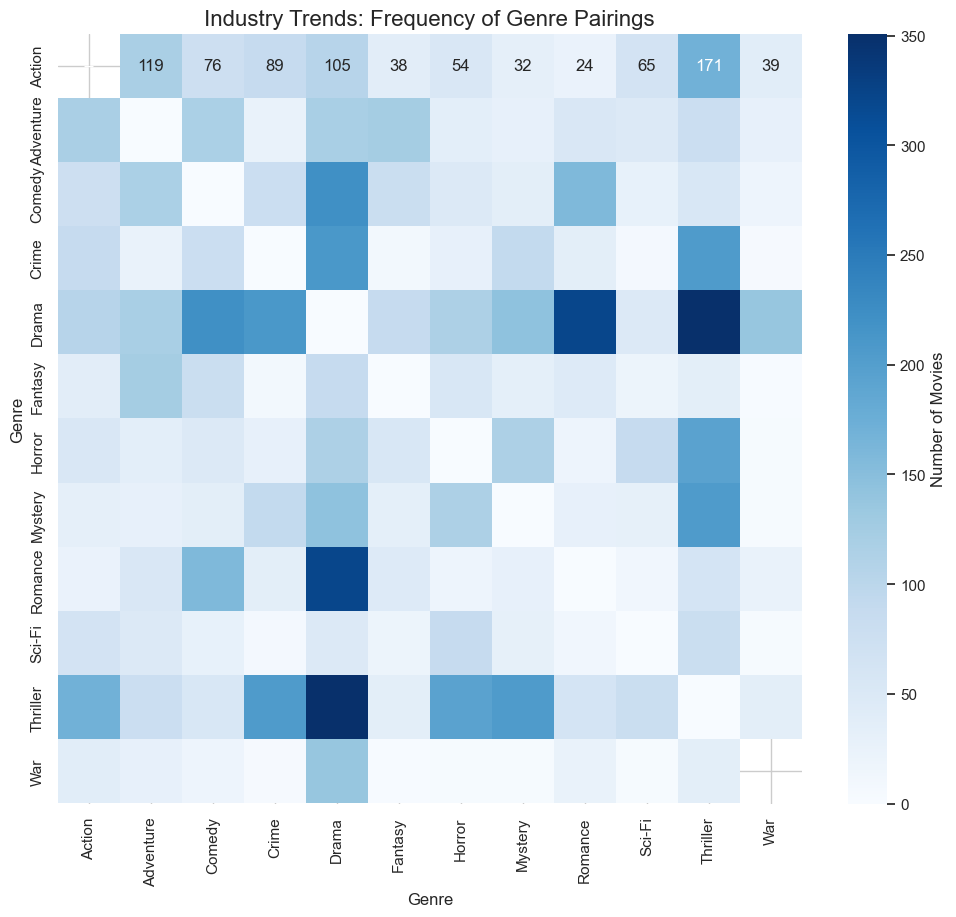

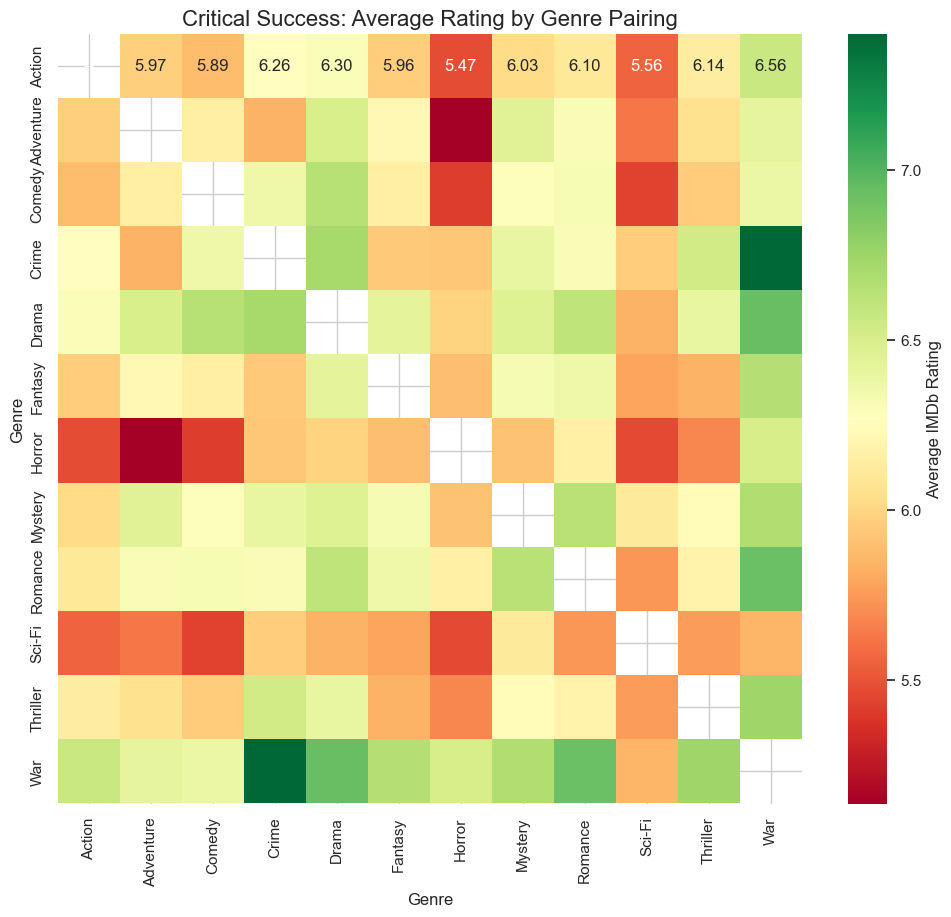

In [106]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

# 1. Preprocessing the genres
# Convert the string of genres into a list for each row
df['genre_list'] = df['genres'].fillna('').str.split(',').apply(
    lambda x: [g.strip() for g in x if g.strip()]
)

# 2. Identify the Top 12 Genres by frequency
# We focus on the most common genres to keep the heatmap clean
all_genres_series = df.explode('genre_list')['genre_list']
top_genres = all_genres_series.value_counts().nlargest(12).index.tolist()

# 3. Extract Pairwise Data
# We create a list of every genre combination found in the movies
pairs_data = []
for _, row in df.iterrows():
    # Filter genres to only include those in our 'top' list
    valid_genres = [g for g in row['genre_list'] if g in top_genres]
    if len(valid_genres) > 1:
        # Create all unique pairs (A, B) within the movie
        for g1, g2 in combinations(sorted(valid_genres), 2):
            pairs_data.append({
                'Genre_A': g1, 
                'Genre_B': g2, 
                'Rating': row['imdbRating']
            })

pairs_df = pd.DataFrame(pairs_data)

# 4. Create Frequency Matrix
# Count how many times each pair occurs
freq_matrix = pairs_df.groupby(['Genre_A', 'Genre_B']).size().unstack().fillna(0)
# Make the matrix symmetrical (mirror the values)
freq_matrix = freq_matrix.add(freq_matrix.T, fill_value=0)

# 5. Create Rating Matrix
# Calculate the mean rating for each pair
rating_matrix = pairs_df.groupby(['Genre_A', 'Genre_B'])['Rating'].mean().unstack()
rating_matrix = rating_matrix.combine_first(rating_matrix.T)

# --- VISUALIZATION 1: Genre Pairing Frequency ---
plt.figure(figsize=(12, 10))
sns.heatmap(freq_matrix, annot=True, fmt='g', cmap='Blues', cbar_kws={'label': 'Number of Movies'})
plt.title('Industry Trends: Frequency of Genre Pairings', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.savefig('../assets/genre_frequency_heatmap.png')

# --- VISUALIZATION 2: Genre Pairing Quality ---
plt.figure(figsize=(12, 10))
sns.heatmap(rating_matrix, annot=True, fmt='.2f', cmap='RdYlGn', cbar_kws={'label': 'Average IMDb Rating'})
plt.title('Critical Success: Average Rating by Genre Pairing', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.savefig('../assets/genre_rating_heatmap.png')

## Network for keywords

In [107]:
import pandas as pd
import itertools
from collections import Counter

# 1. Preparation: Clean keywords and filter for significance
# Splitting keywords into lists and removing whitespace
df['keyword_list'] = df['keywords'].fillna('').str.split(',')
df['keyword_list'] = df['keyword_list'].apply(lambda x: [k.strip().lower() for k in x if k.strip()])

# Optional: Filter for the top X keywords to avoid a "hairball" network
all_kw = [kw for sublist in df['keyword_list'] for kw in sublist]
top_kw_counts = Counter(all_kw).most_common(200) # Adjust 200 to your preference
top_kw_set = set([k[0] for k in top_kw_counts])

# 2. Generate EDGES (Keyword A <-> Keyword B)
edges_list = []

for _, row in df.iterrows():
    # Only use keywords that are in our 'Top' set for a cleaner graph
    valid_kws = [k for k in row['keyword_list'] if k in top_kw_set]
    
    # Create combinations (Pairs) of keywords within the same movie
    if len(valid_kws) > 1:
        # sorted() ensures we don't get (A,B) and (B,A) as separate entries
        pairs = list(itertools.combinations(sorted(valid_kws), 2))
        edges_list.extend(pairs)

# Convert to DataFrame and aggregate weights
edges_df = pd.DataFrame(edges_list, columns=['Source', 'Target'])
gephi_edges = edges_df.groupby(['Source', 'Target']).size().reset_index(name='Weight')

# 3. Generate NODES
nodes_data = [{'Id': k, 'Label': k} for k in top_kw_set]
gephi_nodes = pd.DataFrame(nodes_data)

# 4. Export
gephi_nodes.to_csv('../assets/data_for_networks/keyword_nodes.csv', index=False)
gephi_edges.to_csv('../assets/data_for_networks/keyword_edges.csv', index=False)

print(f"Network files ready! Unique Nodes: {len(gephi_nodes)}, Connections: {len(gephi_edges)}")

Network files ready! Unique Nodes: 200, Connections: 19899


In [108]:
import pandas as pd
import itertools
import xml.etree.ElementTree as ET
from xml.dom import minidom
from collections import Counter

# 1. Preparation
df['keyword_list'] = df['keywords'].fillna('').str.split(',')
df['keyword_list'] = df['keyword_list'].apply(lambda x: [k.strip().lower() for k in x if k.strip()])

# Filter for top 100 keywords
all_kw = [kw for sublist in df['keyword_list'] for kw in sublist]
top_kw_counts = Counter(all_kw).most_common(100) 
top_kw_set = set([k[0] for k in top_kw_counts])

# 2. Calculate Performance Stats per Keyword
# We create a mapping: keyword -> list of ratings/votes
kw_ratings = {k: [] for k in top_kw_set}
kw_votes = {k: [] for k in top_kw_set}

for _, row in df.iterrows():
    for k in row['keyword_list']:
        if k in top_kw_set:
            kw_ratings[k].append(row['imdbRating'])
            kw_votes[k].append(row['numberOfVotes'])

# Average them out
kw_stats = {
    k: {
        'avg_rating': sum(kw_ratings[k]) / len(kw_ratings[k]) if kw_ratings[k] else 0,
        'avg_votes': sum(kw_votes[k]) / len(kw_votes[k]) if kw_votes[k] else 0,
        'count': len(kw_ratings[k])
    } for k in top_kw_set
}

# 3. Generate EDGES (with higher threshold to fix the "99 degree" problem)
kw_edges_list = []
for _, row in df.iterrows():
    valid_kws = [k for k in row['keyword_list'] if k in top_kw_set]
    if len(valid_kws) > 1:
        pairs = list(itertools.combinations(sorted(valid_kws), 2))
        kw_edges_list.extend(pairs)

kw_edges_df = pd.DataFrame(kw_edges_list, columns=['source', 'target'])
gephi_kw_edges = kw_edges_df.groupby(['source', 'target']).size().reset_index(name='weight')
# FILTER: Increase this if the graph is still too crowded
gephi_kw_edges = gephi_kw_edges[gephi_kw_edges['weight'] > 110] 

# 4. Build GEXF XML
gexf = ET.Element('gexf', xmlns='http://www.gexf.net/1.2draft', version='1.2')
graph = ET.SubElement(gexf, 'graph', defaultedgetype='undirected')

# Define Attributes
attributes = ET.SubElement(graph, 'attributes', {'class': 'node'})
ET.SubElement(attributes, 'attribute', id='0', title='avg_rating', type='float')
ET.SubElement(attributes, 'attribute', id='1', title='avg_votes', type='float')
ET.SubElement(attributes, 'attribute', id='2', title='movie_count', type='integer')

nodes_element = ET.SubElement(graph, 'nodes')
for kw, stats in kw_stats.items():
    node = ET.SubElement(nodes_element, 'node', id=kw, label=kw)
    attvalues = ET.SubElement(node, 'attvalues')
    ET.SubElement(attvalues, 'attvalue', {'for': '0', 'value': str(round(stats['avg_rating'], 2))})
    ET.SubElement(attvalues, 'attvalue', {'for': '1', 'value': str(round(stats['avg_votes'], 0))})
    ET.SubElement(attvalues, 'attvalue', {'for': '2', 'value': str(stats['count'])})

edges_element = ET.SubElement(graph, 'edges')
for i, row in gephi_kw_edges.iterrows():
    ET.SubElement(edges_element, 'edge', {
        'id': f"kwe_{i}", 
        'source': str(row['source']), 
        'target': str(row['target']), 
        'weight': str(row['weight'])
    })

# Save
xml_str = ET.tostring(gexf, encoding='utf-8')
pretty_xml = minidom.parseString(xml_str).toprettyxml(indent="  ")
with open('../assets/data_for_networks/keyword_performance_network.gexf', "w", encoding="utf-8") as f:
    f.write(pretty_xml)

print(f"Keyword GEXF ready! Nodes: {len(top_kw_set)}, Edges: {len(gephi_kw_edges)}")

Keyword GEXF ready! Nodes: 100, Edges: 583


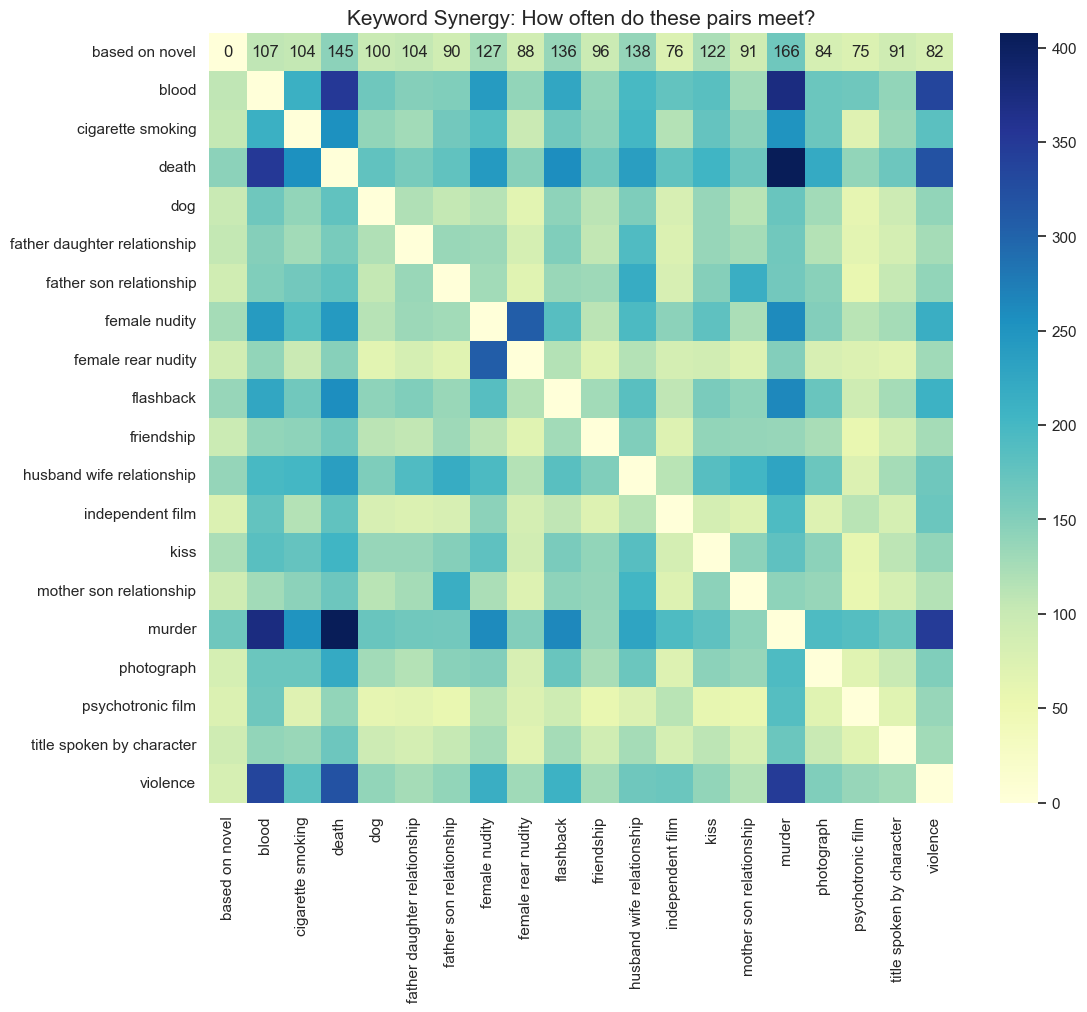

/Users/meike/anaconda3/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


<Figure size 640x480 with 0 Axes>

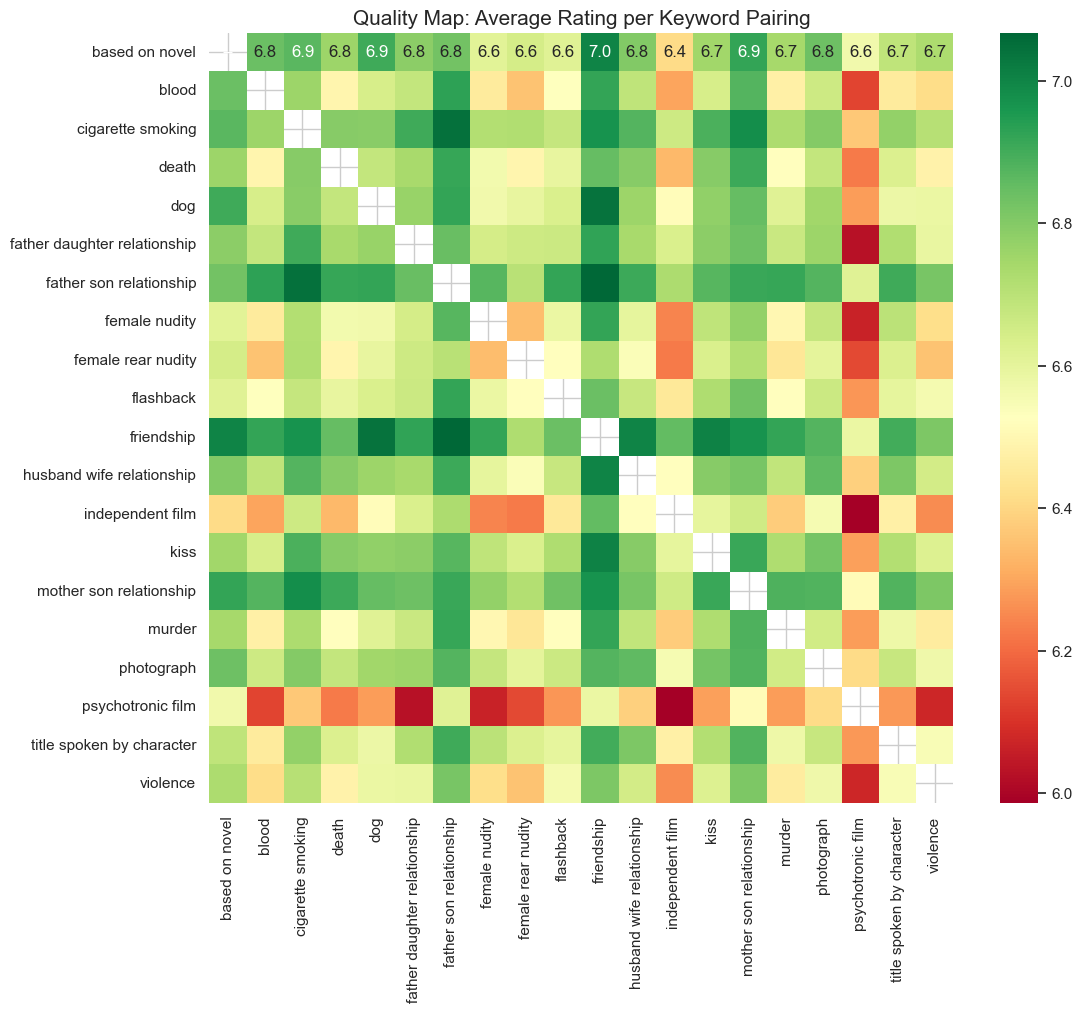

<Figure size 640x480 with 0 Axes>

In [109]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

# 1. Prepare data for top 20 keywords (to keep heatmaps readable)
top_20_kw = [k[0] for k in top_kw_counts[:20]]

# 2. Extract pairs and their performance
heatmap_data = []
for _, row in df.iterrows():
    valid = [k for k in row['keyword_list'] if k in top_20_kw]
    if len(valid) > 1:
        for g1, g2 in combinations(sorted(valid), 2):
            heatmap_data.append({
                'KW1': g1, 'KW2': g2, 
                'Rating': row['imdbRating'], 
                'Votes': row['numberOfVotes']
            })

h_df = pd.DataFrame(heatmap_data)

# 3. Create the Matrix Functions
def create_matrix(df, value_col, agg_func):
    matrix = df.groupby(['KW1', 'KW2'])[value_col].agg(agg_func).unstack()
    return matrix.combine_first(matrix.T).fillna(0)

# --- VISUALIZATION 1: Co-occurrence (The "Industry Standard") ---
plt.figure(figsize=(12, 10))
freq_mat = create_matrix(h_df, 'Rating', 'count')
sns.heatmap(freq_mat, annot=True, fmt='g', cmap='YlGnBu')
plt.title('Keyword Synergy: How often do these pairs meet?', fontsize=15)
plt.show()
plt.savefig('../assets/keyword_frequency_heatmap.png')

# --- VISUALIZATION 2: Critical Success (The "Award Winners") ---
plt.figure(figsize=(12, 10))
rating_mat = create_matrix(h_df, 'Rating', 'mean')
# Filter out low-frequency pairs to avoid skewed averages
rating_mat[freq_mat < 3] = None 
sns.heatmap(rating_mat, annot=True, fmt='.1f', cmap='RdYlGn')
plt.title('Quality Map: Average Rating per Keyword Pairing', fontsize=15)
plt.show()
plt.savefig('../assets/keywords_rating_heatmap.png')

## Combi Network keywords and genre

this alloweds to filter in gephi for a genre and see the keywords that are mostly used in this genre. 

first try filters for the 60 most used keywords in he whole data set. The network shows which genre uses which of these most common keywords. Can be filtered for specific genre or keyword.

In [110]:
import pandas as pd
import xml.etree.ElementTree as ET
from xml.dom import minidom
from collections import Counter

# 1. Preparation
df['genre_list'] = df['genres'].fillna('').str.split(',').apply(lambda x: [g.strip() for g in x if g.strip()])
df['kw_list'] = df['keywords'].fillna('').str.split(',').apply(lambda x: [k.strip().lower() for k in x if k.strip()])

# Filter for Top 60 Keywords
all_kw = [k for sublist in df['kw_list'] for k in sublist]
top_kw = [k[0] for k in Counter(all_kw).most_common(60)]

# 2. Map Keywords to their "Primary Genre"
# We find which genre each keyword appears in most frequently
kw_to_genre_counts = {k: Counter() for k in top_kw}
for _, row in df.iterrows():
    for g in row['genre_list']:
        for k in row['kw_list']:
            if k in top_kw:
                kw_to_genre_counts[k][g] += 1

primary_genre_map = {k: counts.most_common(1)[0][0] for k, counts in kw_to_genre_counts.items() if counts}

# 3. Build GEXF
gexf = ET.Element('gexf', xmlns='http://www.gexf.net/1.2draft', version='1.2')
graph = ET.SubElement(gexf, 'graph', defaultedgetype='undirected')

# Attributes
attributes = ET.SubElement(graph, 'attributes', {'class': 'node'})
ET.SubElement(attributes, 'attribute', id='0', title='PrimaryGenre', type='string')
ET.SubElement(attributes, 'attribute', id='1', title='NodeType', type='string')

nodes_element = ET.SubElement(graph, 'nodes')
all_genres = sorted(list(set([g for sublist in df['genre_list'] for g in sublist])))

# Add Genre Nodes (PrimaryGenre = itself)
for g in all_genres:
    node = ET.SubElement(nodes_element, 'node', id=f"G_{g}", label=g)
    attvals = ET.SubElement(node, 'attvalues')
    ET.SubElement(attvals, 'attvalue', {'for': '0', 'value': g})
    ET.SubElement(attvals, 'attvalue', {'for': '1', 'value': 'Genre'})

# Add Keyword Nodes (PrimaryGenre = the genre it appears in most)
for k in top_kw:
    node = ET.SubElement(nodes_element, 'node', id=f"K_{k}", label=k)
    attvals = ET.SubElement(node, 'attvalues')
    ET.SubElement(attvals, 'attvalue', {'for': '0', 'value': primary_genre_map.get(k, 'Unknown')})
    ET.SubElement(attvals, 'attvalue', {'for': '1', 'value': 'Keyword'})

# Add Edges (Genre <-> Keyword)
edges_element = ET.SubElement(graph, 'edges')
edge_id = 0
for k, counts in kw_to_genre_counts.items():
    for g, weight in counts.items():
        if weight > 3: # Threshold to keep it clean
            ET.SubElement(edges_element, 'edge', {
                'id': str(edge_id),
                'source': f"G_{g}",
                'target': f"K_{k}",
                'weight': str(weight)
            })
            edge_id += 1

# 4. Save
xml_str = ET.tostring(gexf, encoding='utf-8')
with open('../assets/data_for_networks/combi_genre_keyword_primary.gexf', "w", encoding="utf-8") as f:
    f.write(minidom.parseString(xml_str).toprettyxml(indent="  "))

creates one network for all genres. no keywords get filtered. good for the not so common genres like documentary

In [116]:
import pandas as pd
import itertools
import xml.etree.ElementTree as ET
from xml.dom import minidom
from collections import Counter
import os

# 1. Setup output directory
output_dir = '../assets/genres_filtered/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 2. Preparation
df['genre_list'] = df['genres'].fillna('').str.split(',').apply(lambda x: [g.strip() for g in x if g.strip()])
df['kw_list'] = df['keywords'].fillna('').str.split(',').apply(lambda x: [k.strip().lower() for k in x if k.strip()])

all_genres = set([g for sublist in df['genre_list'] for g in sublist])

# 3. Loop through each genre
for target_genre in all_genres:
    genre_df = df[df['genre_list'].apply(lambda x: target_genre in x)].copy()
    
    if len(genre_df) < 5:
        continue

    # Count keyword frequency WITHIN this genre
    kw_frequency = Counter([kw for sublist in genre_df['kw_list'] for kw in sublist])
    
    # FILTER: Only keep keywords that appear at least 3 times in this genre
    min_keyword_frequency = 3
    valid_keywords = {k for k, count in kw_frequency.items() if count >= min_keyword_frequency}

    # Generate Edges for valid keywords only
    kw_edges = []
    for _, row in genre_df.iterrows():
        # Only use keywords that passed the frequency filter
        kws = sorted([k for k in set(row['kw_list']) if k in valid_keywords])
        
        if len(kws) > 1:
            pairs = list(itertools.combinations(kws, 2))
            kw_edges.extend(pairs)

    edge_counts = Counter(kw_edges)
    
    # Final check: only nodes that have at least one connection
    nodes_with_edges = set()
    for (s, t) in edge_counts.keys():
        nodes_with_edges.add(s)
        nodes_with_edges.add(t)

    # 4. Build GEXF
    gexf = ET.Element('gexf', xmlns='http://www.gexf.net/1.2draft', version='1.2')
    graph = ET.SubElement(gexf, 'graph', defaultedgetype='undirected')
    
    attributes = ET.SubElement(graph, 'attributes', {'class': 'node'})
    ET.SubElement(attributes, 'attribute', id='0', title='Frequency', type='integer')

    nodes_element = ET.SubElement(graph, 'nodes')
    for k in nodes_with_edges:
        node = ET.SubElement(nodes_element, 'node', id=k, label=k)
        att = ET.SubElement(node, 'attvalues')
        ET.SubElement(att, 'attvalue', {'for': '0', 'value': str(kw_frequency[k])})

    edges_element = ET.SubElement(graph, 'edges')
    for i, ((source, target), weight) in enumerate(edge_counts.items()):
        ET.SubElement(edges_element, 'edge', {
            'id': str(i),
            'source': source,
            'target': target,
            'weight': str(weight)
        })

    # 5. Save
    xml_str = ET.tostring(gexf, encoding='utf-8')
    filename = f"{target_genre.replace(' ', '_')}_filtered.gexf"
    with open(os.path.join(output_dir, filename), "w", encoding="utf-8") as f:
        f.write(minidom.parseString(xml_str).toprettyxml(indent="  "))

print(f"Cleaned networks generated in {output_dir}")

: 

: 